## HCP individualized connectome prediction evaluation

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from sklearn.decomposition import PCA

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import torch
from torch.utils.data import Dataset, DataLoader

In [3]:
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch

In [14]:
# --- Reloadable utility to keep notebook state fresh when editing code ---
import importlib

# --- Data loading and utils (see Conn2Conn/data/) ---
from data.hcp_dataset import HCP_Base, HCP_Partition
import data.hcp_dataset
import data.dataset_utils
import data.data_utils
importlib.reload(data.hcp_dataset)
importlib.reload(data.dataset_utils)
importlib.reload(data.data_utils)
from data.hcp_dataset import *
from data.dataset_utils import *
from data.data_utils import *

# --- Model definitions and core model imports (see Conn2Conn/models/) ---
import models
importlib.reload(models)
from models import *

# --- Evaluation utilities (models/eval.py, models/eval_utils.py, models/loss.py) ---
import models.eval
importlib.reload(models.eval)
from models.eval import *

import models.eval_utils
importlib.reload(models.eval_utils)
from models.eval_utils import *

import models.loss
importlib.reload(models.loss)
from models.loss import *

import main
importlib.reload(main)
from main import *

In [15]:
import importlib

import models.models
import models.config
import models.loss
import models.lightning_module
import models.eval
import main

importlib.reload(models.models)
importlib.reload(models.loss)
importlib.reload(models.lightning_module)
importlib.reload(models.config)
importlib.reload(models.eval)
importlib.reload(main)

from main import Sim

## CrossModal_PCA_PLS_CovProjector testing

In [9]:
# --- Setup Sim for CovProjector (same pattern as test_models FS projector) ---
CONN2CONN_DIR = "/scratch/asr655/neuroinformatics/Conn2Conn"
os.chdir(CONN2CONN_DIR)

sim = Sim(
    model_name="CrossModal_PCA_PLS_CovProjector",
    config_path=os.path.join(CONN2CONN_DIR, "models/configs/CrossModal_PCA_PLS_CovProjector.yml"),
    source="SC",
    target="FC"
)
print("cov_sources:", sim.base.cov_sources)
print("cov_dims:", sim.base.cov_dims)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


cov_sources: ['fs_all', 'fs_volumes', 'age', 'sex', 'race_eth']
cov_dims: {'fs_all': 199, 'fs_volumes': 16, 'age': 1, 'sex': 2, 'race_eth': 7}


In [10]:
# --- Build the CovProjector model from config (same as main.py) ---
from models.config import build_model, get_default_config, resolve_source_dependent_config

cfg = sim._merge_config(None)  # merged default + data
cfg = resolve_source_dependent_config(cfg)
model_cfg = cfg["model"].copy()
model_cfg.pop("name")

model = build_model(sim.base, "CrossModal_PCA_PLS_CovProjector", model_cfg)
model.eval()
print("Model params (trainable):", model.get_num_params())

/ext3/miniforge3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


CovProjector init: source_dims={'SC': 256}, target_dim=256, cov_sources=['fs_all', 'fs_volumes', 'age', 'sex', 'race_eth']
Model params (trainable): 36132


/ext3/miniforge3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /scratch/asr655/neuroinformatics/Conn2Conn/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name    | Type 

CovProjector init: source_dims={'SC': 256}, target_dim=256, cov_sources=['fs_all', 'fs_volumes']


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=79` in the `DataLoader` to improve performance.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=79` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=175` reached.



Training complete!


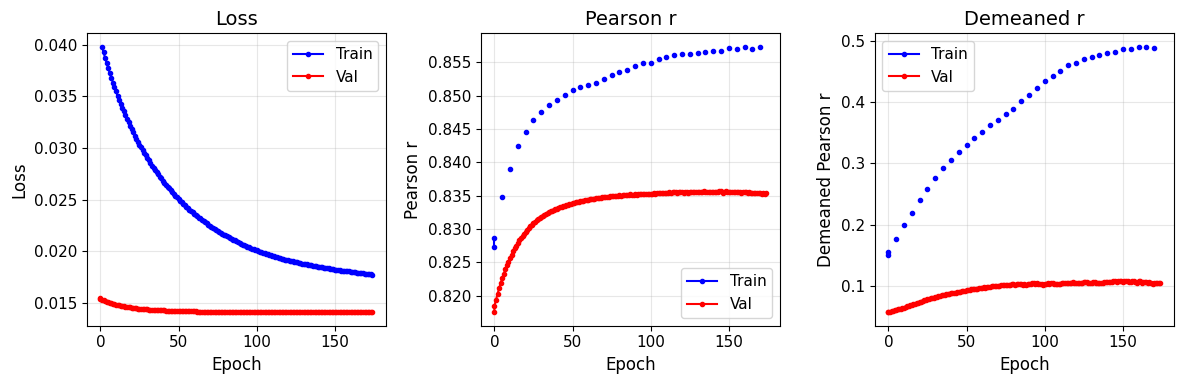

Number of unique demographic categories: 14
Top-1 accuracy: 0.067  (13 of 195 subjects had rank 1) (chance=0.005)
Average rank percentile: 0.682 (chance=0.5)


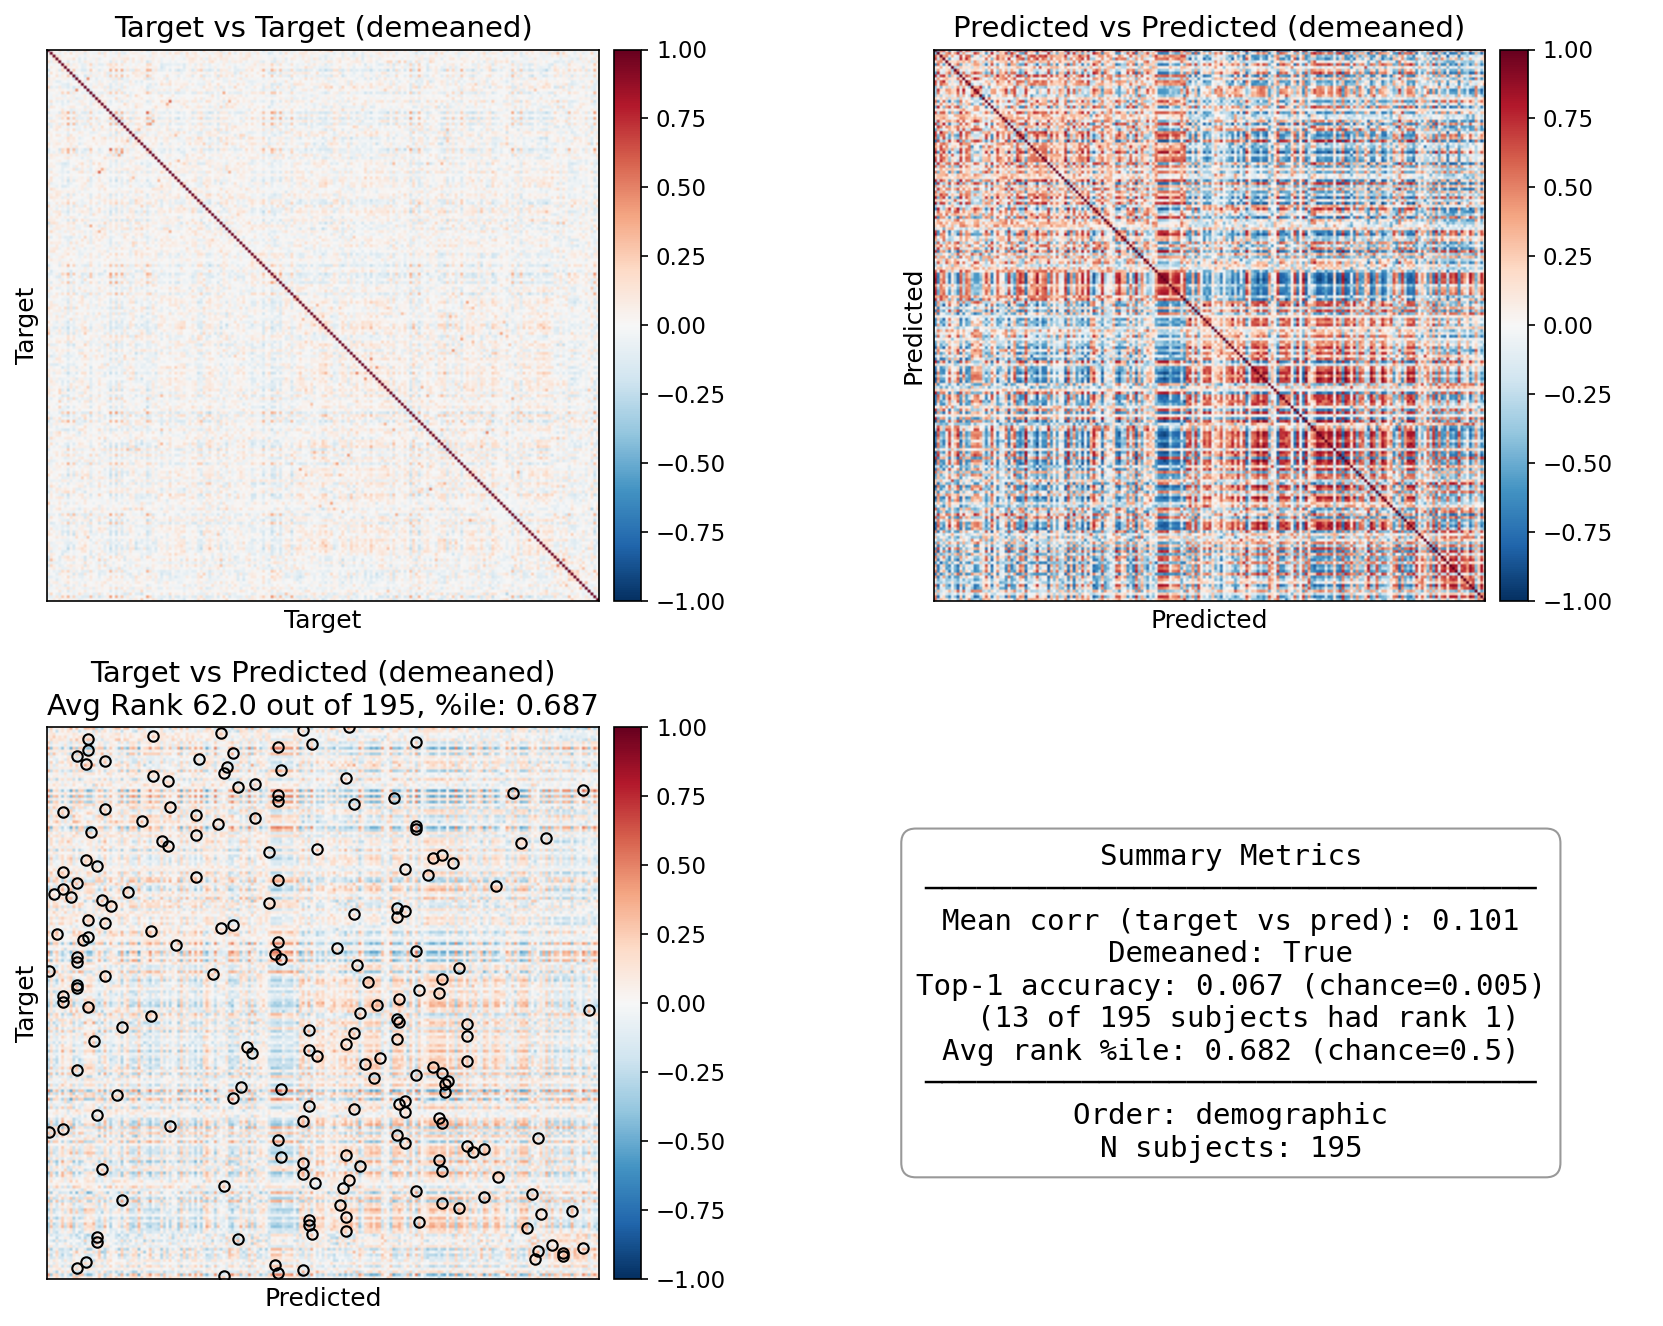

returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]


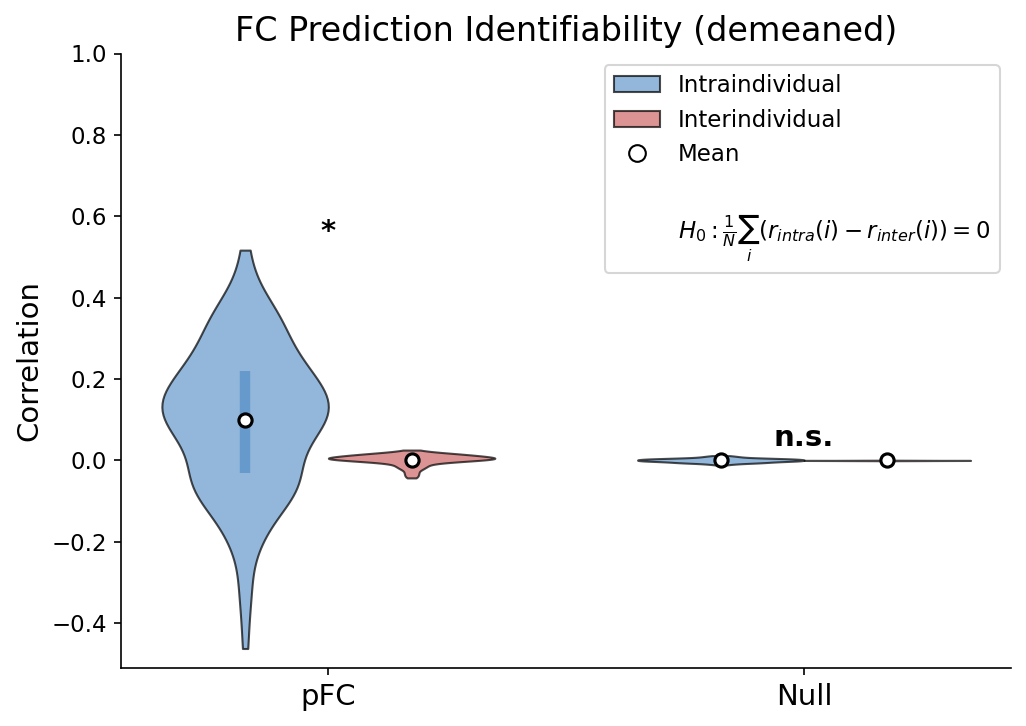


Identifiability Summary:
Condition    r_intra    r_inter    d          t          p            Cohen d   
----------------------------------------------------------------------
pFC          0.1006     0.0019     0.0987     7.71       6.39e-13     0.55      
Null         0.0004     -0.0001    0.0005     1.35       1.78e-01     0.10      


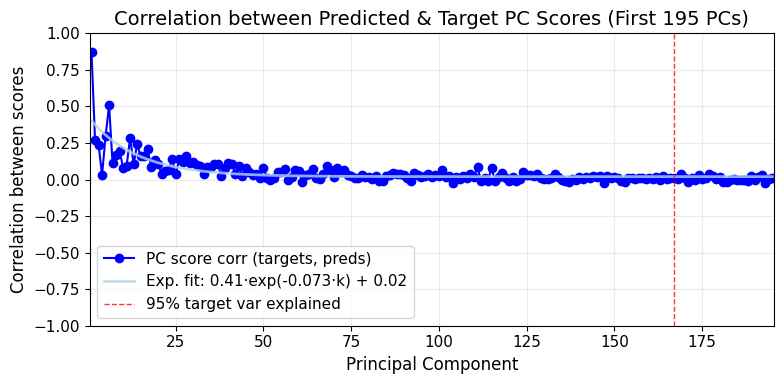

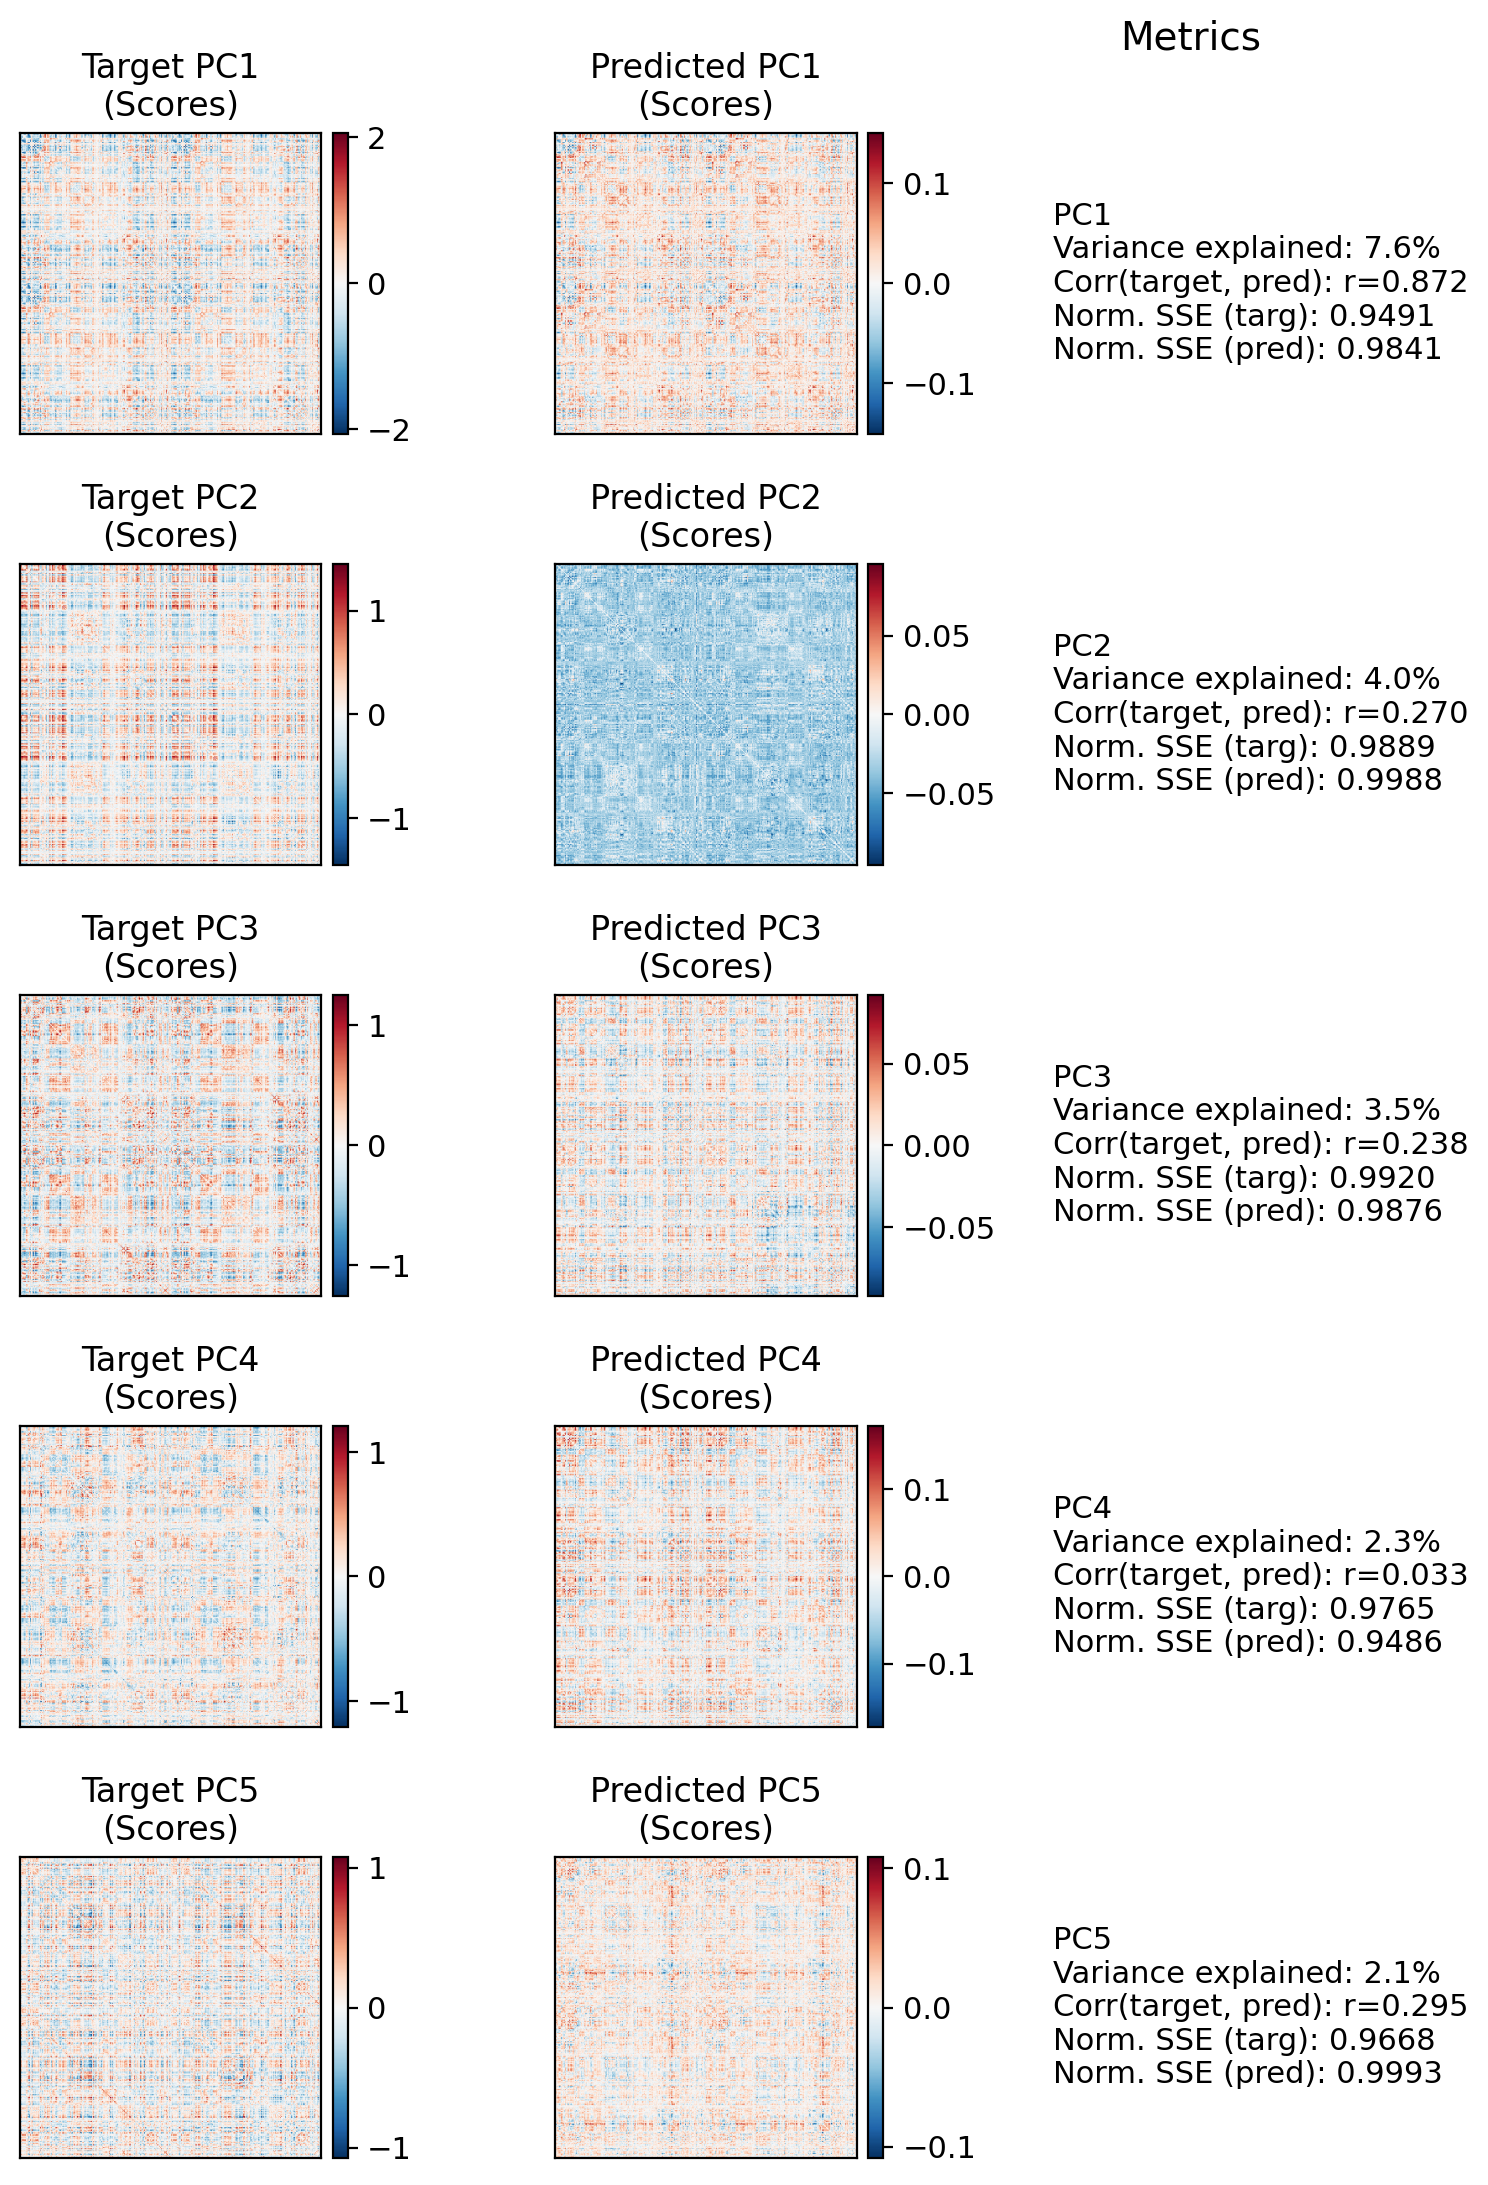

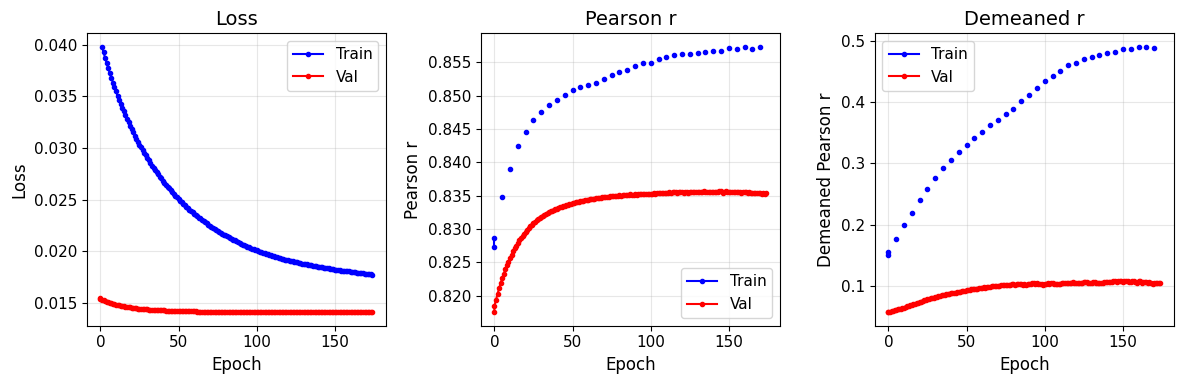

Test metrics: {'mse': np.float32(0.013211983), 'r2': np.float32(-0.00237457), 'pearson': np.float32(0.84042215), 'demeaned_pearson': np.float64(0.10056947745737468), 'avg_rank': np.float64(0.6766074950690335), 'top1_acc': np.float64(0.05641025641025641)}


In [25]:
# Dynamically use only linear fs_all (subset of sim.base cov_sources). No need to recreate Sim.
result = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override={
        "model": {
            "n_components_pca_source": 256,
            "n_components_pca_target": 256,
            "n_components_pls": 16,
            "learn_encoder": False,
            "learn_mid": True,
            "learn_decoder": False,
            "random_init": False,
            "l1_l2_tuple": [0.0, 0.0001],
            "dropout": 0.1,
            "cov_sources": ["fs_all", "fs_volumes"], #, "age", "sex", "race_eth"],
            "cov_projectors": {
                "fs_all":     {"type": "linear", "out_dim": 64},
                "fs_volumes": {"type": "linear", "out_dim": 16},
                #"age":        {"type": "linear", "out_dim": 4},
                #"sex":        {"type": "linear", "out_dim": 4},
                #"race_eth":   {"type": "linear", "out_dim": 8}
            },
            "cov_fusion": {
                "type": "mlp",
                "hidden_dims": [64],
                "dropout": 0.1,
                "layer_norm": True,
            },
            "use_target_scores_in_projector": False,
            "target_scores_projector": {
                "type": "linear",
                "hidden_dims": [64]
            },
        },
        "trainer": {
            "lr": 9e-5,
            "loss_type": "mse",
            "max_epochs": 175,
            "batch_size": 128,
            "log_every": 5,
        }
    },
)
model = result["model"]
if result.get("train_result") is not None:
    result["train_result"].plot()
print("Test metrics:", result.get("test_metrics", {}).get("base_metrics"))